In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
dataset_forwards = pd.read_excel("premier_league_25_26_forwards.xlsx")

In [3]:
dataset_forwards.head()

,accurateChippedPasses,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,accuratePasses,accuratePassesPercentage,...,totalShots,totwAppearances,touches,wasFouled,yellowCards,yellowRedCards,player,team,player id,team id
0,5,1,33.33,107,4,28.57,160,92,252,65.63,...,126,6,778,25,2,0,Erling Haaland,Manchester City,839956,17
1,15,40,32.79,341,14,35.90,476,117,593,76.71,...,71,5,1382,54,2,0,Bukayo Saka,Arsenal,934235,42
2,13,1,5.56,196,11,50.00,345,177,522,75.32,...,73,3,1246,56,5,0,João Pedro,Chelsea,975079,38
3,25,11,22.00,283,22,52.38,470,238,708,80.45,...,90,3,1515,54,4,0,Matheus Cunha,Manchester United,886363,35
4,10,15,21.43,203,17,65.38,307,116,423,81.82,...,48,2,937,40,3,0,Anthony Gordon,Newcastle United,914902,39


In [4]:
dataset_forwards.shape

(105, 114)

In [5]:
dataset_forwards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Columns: 114 entries, accurateChippedPasses to team id
dtypes: float64(17), int64(95), object(2)
memory usage: 93.6+ KB


In [6]:
dataset_forwards.columns

Index(['accurateChippedPasses', 'accurateCrosses', 'accurateCrossesPercentage',
       'accurateFinalThirdPasses', 'accurateLongBalls',
       'accurateLongBallsPercentage', 'accurateOppositionHalfPasses',
       'accurateOwnHalfPasses', 'accuratePasses', 'accuratePassesPercentage',
       ...
       'totalShots', 'totwAppearances', 'touches', 'wasFouled', 'yellowCards',
       'yellowRedCards', 'player', 'team', 'player id', 'team id'],
      dtype='object', length=114)

In [7]:
# Keep only relevant features for offensive player profiling, removing redundant, low-relevance, or noisy metrics
features = [

    # Offensive output
    "goals",
    "assists",
    "expectedGoals",
    "expectedAssists",

    # Physicality/duels
    "aerialDuelsWon",
    "groundDuelsWon",
    "ballRecovery",
    "possessionWonAttThird",
    "tacklesWon",

    # Participation in build-up
    "accurateFinalThirdPasses",
    "accurateOppositionHalfPasses",
    "touches",

    # Creation
    "bigChancesCreated",
    "keyPasses",

    # Shooting
    "shotsOnTarget",

    # Dribbling
    "successfulDribbles",

    # IDs
    "player",
    "team",
    "minutesPlayed"
]

"""
The remaining features were removed mainly due to redundancy, low tactical relevance for forwards, 
or excessive statistical noise. Very specific metrics, such as leftFootGoals, offsides, wasFouled, 
and accurateChippedPasses, make cluster interpretation more difficult without adding meaningful 
information. Percentage-based statistics, such as accurateCrossesPercentage and aerialDuelsWonPercentage, 
may distort results for players with a low volume of actions. In addition, goalkeeper-related statistics 
(saves, punches), penalty-related metrics (penaltiesTaken, penaltyGoals), defensive actions with low 
relevance for attacking profiling (interceptions, clearances), inefficiency indicators (duelLost, shotsOffTarget, 
possessionLost), and rare events (redCards, freeKickGoal) do not contribute consistently to distinguishing 
offensive playing styles, while potentially introducing bias, noise, and redundancy.
"""

dataset_forwards = dataset_forwards[features].copy()
dataset_forwards.columns

Index(['goals', 'assists', 'expectedGoals', 'expectedAssists',
       'aerialDuelsWon', 'groundDuelsWon', 'ballRecovery',
       'possessionWonAttThird', 'tacklesWon', 'accurateFinalThirdPasses',
       'accurateOppositionHalfPasses', 'touches', 'bigChancesCreated',
       'keyPasses', 'shotsOnTarget', 'successfulDribbles', 'player', 'team',
       'minutesPlayed'],
      dtype='object')

In [8]:
# Remove players with less than 630 minutes played (7 full matches) to ensure a more reliable analysis
dataset_forwards = dataset_forwards[dataset_forwards["minutesPlayed"] >= 630]
dataset_forwards.shape

(68, 19)

In [9]:
# Divide the stats by minutes played and multiply by 90 to get per 90 minutes stats
for col in dataset_forwards.columns:
    if col not in ["player", "team", "minutesPlayed"]:
        dataset_forwards[col] = dataset_forwards[col] / (dataset_forwards["minutesPlayed"] / 90)

dataset_forwards.head()

,goals,assists,expectedGoals,expectedAssists,aerialDuelsWon,groundDuelsWon,ballRecovery,possessionWonAttThird,tacklesWon,accurateFinalThirdPasses,accurateOppositionHalfPasses,touches,bigChancesCreated,keyPasses,shotsOnTarget,successfulDribbles,player,team,minutesPlayed
0,0.821501,0.243408,0.773732,0.086714,2.221095,1.734280,1.247465,0.395538,0.273834,3.255578,4.868154,23.671400,0.273834,0.760649,1.795132,0.517241,Erling Haaland,Manchester City,2958
1,0.283146,0.202247,0.305393,0.289618,0.889888,5.865169,4.732584,1.092135,0.849438,13.793258,19.253933,55.901124,0.485393,2.548315,1.092135,2.022472,Bukayo Saka,Arsenal,2225
2,0.504862,0.168287,0.503515,0.067315,2.490651,4.106208,2.423336,0.538519,0.605834,6.596859,11.611818,41.937173,0.201945,0.976066,0.942408,1.346298,João Pedro,Chelsea,2674
3,0.359569,0.071914,0.253855,0.117938,1.006792,4.890132,4.566520,0.719137,0.827008,10.175789,16.899720,54.474630,0.143827,1.258490,1.258490,1.582101,Matheus Cunha,Manchester United,2503
4,0.297193,0.099064,0.437369,0.166924,0.396258,4.556962,2.823335,0.495322,0.643919,10.055036,15.206384,46.411668,0.247661,1.287837,0.990644,1.634562,Anthony Gordon,Newcastle United,1817


In [10]:
dataset_forwards.describe()

,goals,assists,expectedGoals,expectedAssists,aerialDuelsWon,groundDuelsWon,ballRecovery,possessionWonAttThird,tacklesWon,accurateFinalThirdPasses,accurateOppositionHalfPasses,touches,bigChancesCreated,keyPasses,shotsOnTarget,successfulDribbles,minutesPlayed
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.305047,0.098063,0.321271,0.087713,1.778042,3.033546,2.757797,0.531043,0.565856,6.499630,10.529626,37.638094,0.178680,0.995530,0.858575,0.906963,1619.029412
std,0.196297,0.089048,0.155005,0.066462,1.512367,1.217762,1.075067,0.218880,0.335454,3.158036,4.755663,9.968914,0.138202,0.503611,0.348224,0.564745,654.647449
min,0.000000,0.000000,0.073354,0.012275,0.167754,0.794702,1.178010,0.132353,0.092593,2.347041,3.881645,22.146597,0.000000,0.000000,0.215569,0.092593,638.000000
25%,0.139994,0.039477,0.203373,0.037453,0.681761,2.202064,1.999208,0.393457,0.300152,4.219473,6.991742,29.712656,0.081540,0.648414,0.599064,0.507612,1074.500000
50%,0.276708,0.076644,0.315178,0.067305,1.166958,2.723036,2.561256,0.518783,0.560626,5.453888,9.158644,36.246391,0.159223,0.925248,0.863399,0.787754,1593.000000
75%,0.468174,0.133048,0.445354,0.123078,2.596427,3.930222,3.343893,0.637732,0.793082,8.773126,14.867637,45.039258,0.234225,1.261937,1.105434,1.187248,2119.000000
max,0.821501,0.367847,0.773732,0.289618,7.041123,5.865169,5.304519,1.334569,1.525424,14.310210,21.748527,55.901124,0.642857,2.548315,1.871560,2.584683,3284.000000


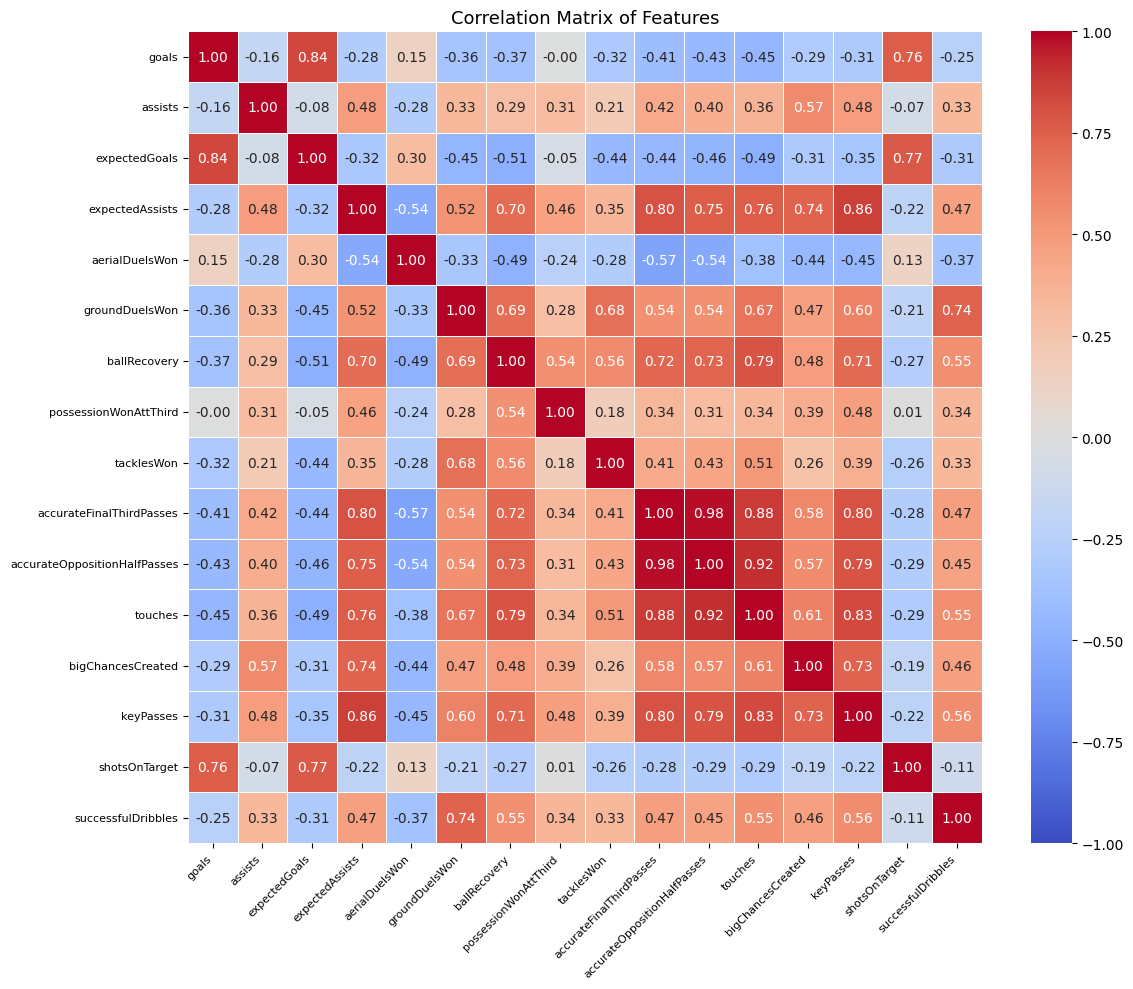

Feature pairs with correlation >= 0.8:


,feature_1,feature_2,correlation
0,accurateFinalThirdPasses,accurateOppositionHalfPasses,0.978413
1,accurateOppositionHalfPasses,touches,0.915678
2,accurateFinalThirdPasses,touches,0.875618
3,expectedAssists,keyPasses,0.862687
4,expectedGoals,goals,0.837529
5,keyPasses,touches,0.832760
6,accurateFinalThirdPasses,expectedAssists,0.801895
7,accurateFinalThirdPasses,keyPasses,0.801865


In [11]:
## Correlation matrix
import seaborn as sns

plt.figure(figsize=(12, 10))
corr_matrix = dataset_forwards.drop(columns=["player", "team", "minutesPlayed"]).corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1  # ensures the color scale ranges from -1 to 1
)
plt.title("Correlation Matrix of Features", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Features with correlation >= 0.8 (absolute value)
corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)

corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]
corr_pairs = corr_pairs[corr_pairs["correlation"] >= 0.8]
corr_pairs = corr_pairs.sort_values("correlation", ascending=False)

print("Feature pairs with correlation >= 0.8:")
display(corr_pairs.reset_index(drop=True))

In [12]:
## Remove highly correlated features

# Remove touches (do not capture participation in build-up as well as accurateFinalThirdPasses and keyPasses do)
dataset_forwards = dataset_forwards.drop(columns=["touches"])

# Remove accurateOppositionHalfPasses (highly correlated with accurateFinalThirdPasses, which is more relevant for profiling forwards)
dataset_forwards = dataset_forwards.drop(columns=["accurateOppositionHalfPasses"])

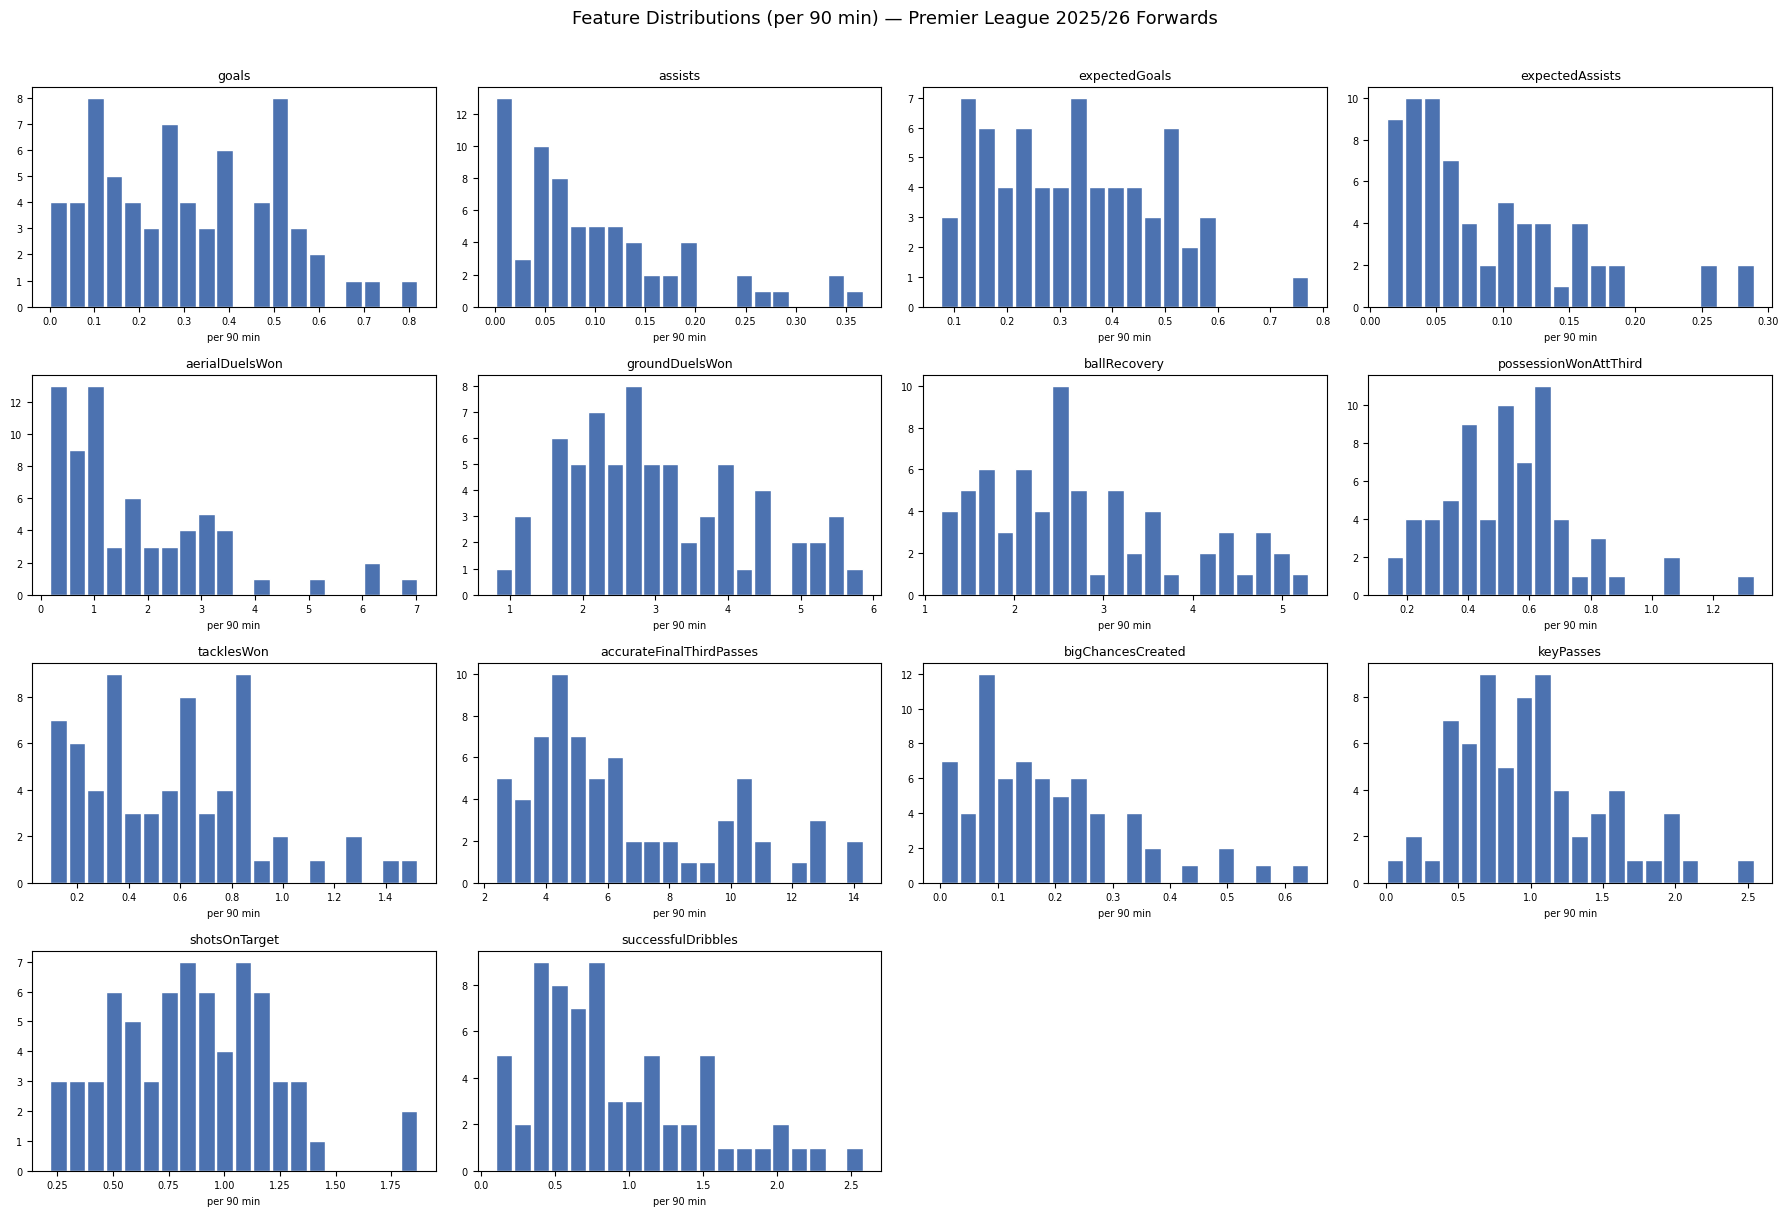

In [13]:
## Feature Distributions

numeric_cols = [c for c in dataset_forwards.columns if c not in ["player", "team", "minutesPlayed"]]

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(dataset_forwards[col], bins=20, color="#4C72B0", edgecolor="white", rwidth=0.9)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("per 90 min", fontsize=7)
    axes[i].tick_params(labelsize=7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions (per 90 min) — Premier League 2025/26 Forwards", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


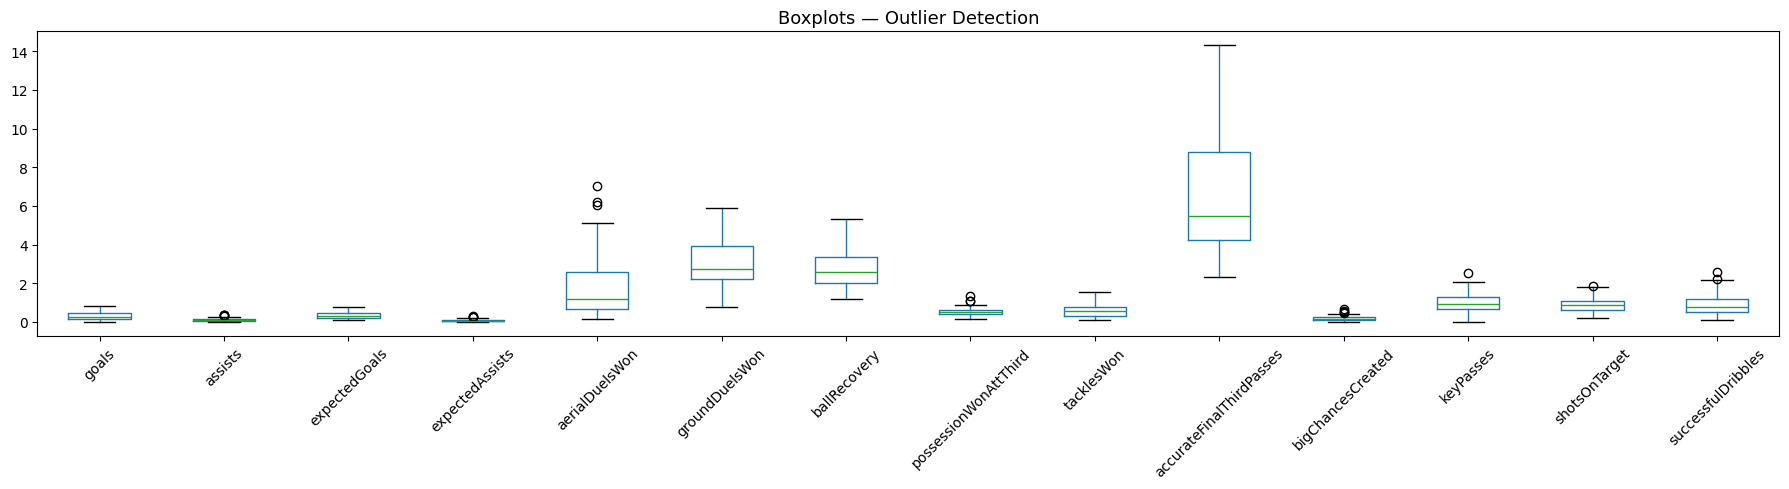

In [14]:
# Boxplots
plt.figure(figsize=(18, 5))
dataset_forwards[numeric_cols].boxplot(rot=45, grid=False)
plt.title("Boxplots — Outlier Detection", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
## Standardization

# Remove columns that do not enter the clustering
X = dataset_forwards.drop(columns=["player", "team", "minutesPlayed"])

feature_names = X.columns

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=feature_names, index=dataset_forwards.index)

X_scaled.head()

,goals,assists,expectedGoals,expectedAssists,aerialDuelsWon,groundDuelsWon,ballRecovery,possessionWonAttThird,tacklesWon,accurateFinalThirdPasses,bigChancesCreated,keyPasses,shotsOnTarget,successfulDribbles
0,2.650550,1.644340,2.940721,-0.015140,0.295132,-1.074862,-1.415318,-0.623688,-0.877002,-1.034875,0.693637,-0.469861,2.709519,-0.695215
1,-0.112400,1.178675,-0.103194,3.060504,-0.591627,2.342557,1.850555,2.582525,0.851652,2.326717,2.235824,3.106226,0.675704,1.989927
2,1.025490,0.794473,1.184478,-0.309195,0.474691,0.887396,-0.313420,0.034410,0.120060,0.031017,0.169594,-0.038936,0.242536,0.783717
3,0.279816,-0.295837,-0.438159,0.458164,-0.513754,1.535924,1.694938,0.865737,0.784289,1.172720,-0.254058,0.526031,1.156980,1.204362
4,-0.040307,0.011329,0.754569,1.200685,-0.920450,1.260298,0.061415,-0.164412,0.234436,1.134199,0.502848,0.584738,0.382084,1.297946


In [16]:
def silhouette_score_2(estimator, X):
    labels = estimator.fit_predict(X)
    score = silhouette_score(X, labels, metric='euclidean')
    return score

In [17]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV with Silhouette Score to find the best K
params = {'n_clusters': np.arange(2, 11)}
model = KMeans(random_state=42)

cluster_gs = GridSearchCV(model, params, n_jobs=-1, scoring=silhouette_score_2)
cluster_gs.fit(X_scaled)

cluster_gs.best_params_['n_clusters']

np.int64(2)

In [18]:
cluster_gs.best_score_

np.float64(0.31662568337915437)

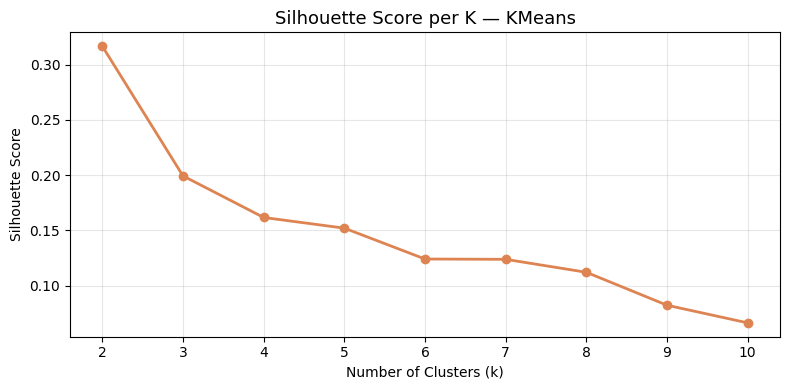

In [19]:
# Silhouette per K plot
cv_results = pd.DataFrame(cluster_gs.cv_results_)

plt.figure(figsize=(8, 4))
plt.plot(
    cv_results["param_n_clusters"].astype(int),
    cv_results["mean_test_score"],
    marker='o', color="#DD8452", linewidth=2
)
plt.title("Silhouette Score per K — KMeans", fontsize=13)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(np.arange(2, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
## Best KMeans Clustering with the best K

best_k_kmeans = cluster_gs.best_params_['n_clusters']
best_kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42)
labels_kmeans = best_kmeans.fit_predict(X_scaled)

dataset_forwards["cluster_kmeans"] = labels_kmeans

print("Cluster distribution (KMeans):")
print(dataset_forwards["cluster_kmeans"].value_counts().sort_index())

Cluster distribution (KMeans):
cluster_kmeans
0    41
1    27
Name: count, dtype: int64


In [21]:
## PCA Visualization of KMeans Clusters
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df_kmeans = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "player": dataset_forwards["player"].values,
    "team": dataset_forwards["team"].values,
    "cluster": dataset_forwards["cluster_kmeans"].astype(str).values
})

fig = px.scatter(
    plot_df_kmeans, x="PC1", y="PC2",
    color="cluster",
    hover_data=["player", "team"],
    title="KMeans — Forward Clustering (Premier League 2025/26)",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=9, opacity=0.85))
fig.update_layout(legend_title_text="Cluster")
fig.show()

In [22]:
## Cluster Profiling for KMeans

cluster_profile_kmeans = (
    dataset_forwards
    .groupby("cluster_kmeans")[feature_names]
    .mean()
    .round(2)
)

print("Cluster Profiles (KMeans):")
display(cluster_profile_kmeans)

Cluster Profiles (KMeans):


,goals,assists,expectedGoals,expectedAssists,aerialDuelsWon,groundDuelsWon,ballRecovery,possessionWonAttThird,tacklesWon,accurateFinalThirdPasses,bigChancesCreated,keyPasses,shotsOnTarget,successfulDribbles
cluster_kmeans,,,,,,,,,,,,,,
0,0.39,0.07,0.4,0.05,2.42,2.36,2.12,0.48,0.42,4.62,0.11,0.71,0.98,0.64
1,0.17,0.14,0.2,0.15,0.80,4.05,3.73,0.61,0.78,9.35,0.28,1.43,0.68,1.31


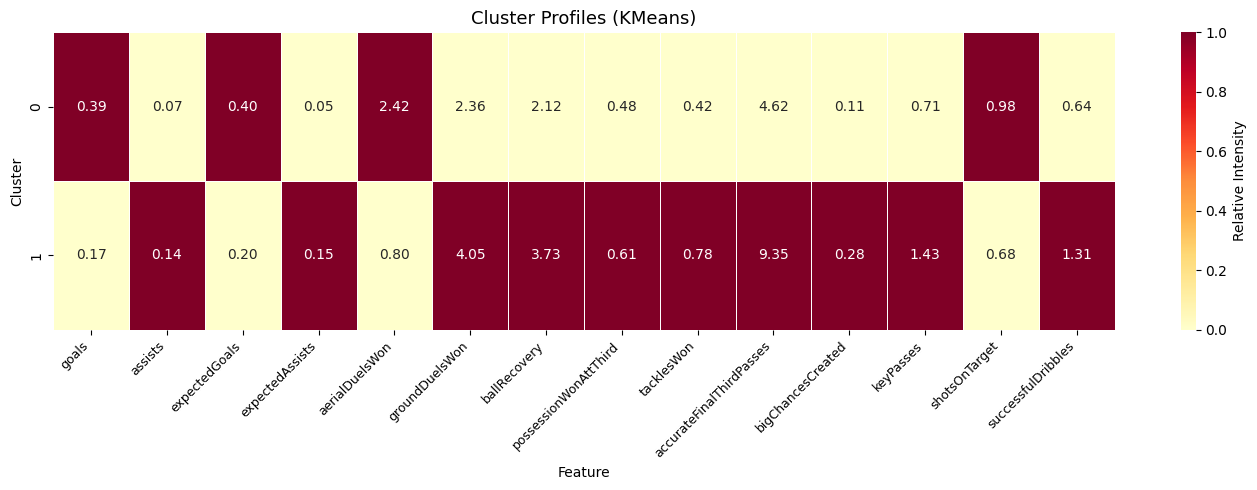

In [23]:
# Heatmap of cluster profiles with normalized colors but real values as annotations
profile_normalized = (cluster_profile_kmeans - cluster_profile_kmeans.min()) / \
                     (cluster_profile_kmeans.max() - cluster_profile_kmeans.min())

plt.figure(figsize=(14, 5))
sns.heatmap(
    profile_normalized,
    annot=cluster_profile_kmeans.values,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relative Intensity"}
)
plt.title("Cluster Profiles (KMeans)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# Test KMeans with K=3

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

dataset_forwards["cluster_kmeans_3"] = labels_kmeans

print("Cluster distribution (KMeans):")
print(dataset_forwards["cluster_kmeans_3"].value_counts().sort_index())

Cluster distribution (KMeans):
cluster_kmeans_3
0    30
1    23
2    15
Name: count, dtype: int64


In [25]:
## PCA Visualization of KMeans Clusters with K=3
from sklearn.decomposition import PCA
import plotly.express as px

plot_df_kmeans = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "player": dataset_forwards["player"].values,
    "team": dataset_forwards["team"].values,
    "cluster": dataset_forwards["cluster_kmeans_3"].astype(str).values
})

fig = px.scatter(
    plot_df_kmeans, x="PC1", y="PC2",
    color="cluster",
    hover_data=["player", "team"],
    title="KMeans — Forward Clustering (Premier League 2025/26)",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=9, opacity=0.85))
fig.update_layout(legend_title_text="Cluster")
fig.show()

In [26]:
## Cluster Profiling for KMeans with K=3

cluster_profile_kmeans_3 = (
    dataset_forwards
    .groupby("cluster_kmeans_3")[feature_names]
    .mean()
    .round(2)
)

print("Cluster Profiles (KMeans):")
display(cluster_profile_kmeans_3)

Cluster Profiles (KMeans):


,goals,assists,expectedGoals,expectedAssists,aerialDuelsWon,groundDuelsWon,ballRecovery,possessionWonAttThird,tacklesWon,accurateFinalThirdPasses,bigChancesCreated,keyPasses,shotsOnTarget,successfulDribbles
cluster_kmeans_3,,,,,,,,,,,,,,
0,0.43,0.05,0.44,0.04,2.62,2.18,1.99,0.46,0.36,4.06,0.09,0.66,1.05,0.56
1,0.22,0.10,0.23,0.09,1.48,3.35,2.98,0.52,0.73,7.17,0.17,0.99,0.65,0.96
2,0.19,0.19,0.23,0.18,0.55,4.26,3.96,0.69,0.73,10.35,0.37,1.68,0.80,1.52


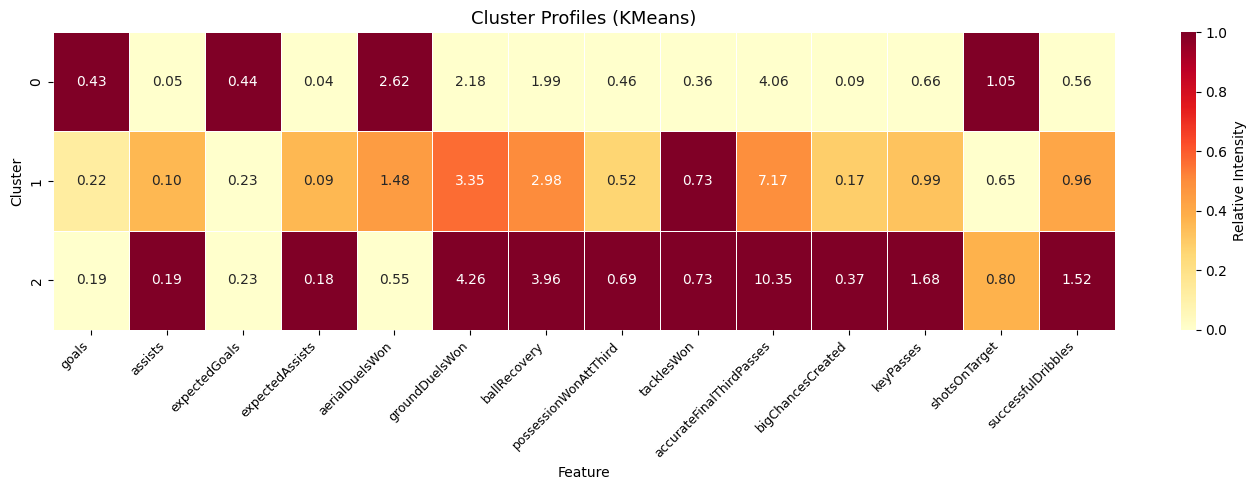

In [27]:
# Heatmap of cluster profiles with normalized colors but real values as annotations
profile_normalized = (cluster_profile_kmeans_3 - cluster_profile_kmeans_3.min()) / \
                     (cluster_profile_kmeans_3.max() - cluster_profile_kmeans_3.min())

plt.figure(figsize=(14, 5))
sns.heatmap(
    profile_normalized,
    annot=cluster_profile_kmeans_3.values,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relative Intensity"}
)
plt.title("Cluster Profiles (KMeans)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
# Players by cluster
print("=== Players by Cluster (KMeans) ===\n")
for c in sorted(dataset_forwards["cluster_kmeans_3"].unique()):
    players = dataset_forwards[dataset_forwards["cluster_kmeans_3"] == c]["player"].tolist()
    print(f"Cluster {c} ({len(players)} players): {', '.join(players)}\n")

=== Players by Cluster (KMeans) ===

Cluster 0 (30 players): Erling Haaland, Igor Thiago, Ollie Watkins, Richarlison, Ismaïla Sarr, Zian Flemming, Eli Junior Kroupi, William Osula, Benjamin Šeško, Jean Philippe Mateta, Valentín Castellanos, Lukas Nmecha, Dominic Calvert-Lewin, Danny Welbeck, Raúl Jiménez, Callum Wilson, Donyell Malen, Wilson Isidor, Brian Brobbey, Beto, Evanilson, Viktor Gyökeres, Chris Wood, Alexander Isak, Tolu Arokodare, Rodrigo Muniz, Thierno Barry, Eliezer Mayenda, Liam Delap, Jørgen Strand Larsen

Cluster 1 (23 players): João Pedro, Noah Okafor, Hugo Ekitiké, Mason Mount, Bryan Mbeumo, Dominic Solanke, Harvey Barnes, Amine Adli, Bertrand Traoré, Nick Woltemade, Brennan Johnson, Adam Armstrong, Anthony Elanga, Igor Jesus, Hwang Hee-chan, Loum Tchaouna, Evann Guessand, Jacob Bruun Larsen, Joshua Zirkzee, Randal Kolo Muani, Lyle Foster, Pablo Felipe, Armando Broja

Cluster 2 (15 players): Bukayo Saka, Matheus Cunha, Anthony Gordon, Leandro Trossard, Amad Diallo, Mat

In [29]:
# Test KMeans with K=4

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

dataset_forwards["cluster_kmeans_4"] = labels_kmeans

print("Cluster distribution (KMeans):")
print(dataset_forwards["cluster_kmeans_4"].value_counts().sort_index())

Cluster distribution (KMeans):
cluster_kmeans_4
0    19
1    27
2     5
3    17
Name: count, dtype: int64


In [30]:
## PCA Visualization of KMeans Clusters with K=4
from sklearn.decomposition import PCA
import plotly.express as px

plot_df_kmeans = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "player": dataset_forwards["player"].values,
    "team": dataset_forwards["team"].values,
    "cluster": dataset_forwards["cluster_kmeans_4"].astype(str).values
})

fig = px.scatter(
    plot_df_kmeans, x="PC1", y="PC2",
    color="cluster",
    hover_data=["player", "team"],
    title="KMeans — Forward Clustering (Premier League 2025/26)",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=9, opacity=0.85))
fig.update_layout(legend_title_text="Cluster")
fig.show()

In [31]:
## Cluster Profiling for KMeans with K=4

cluster_profile_kmeans_4 = (
    dataset_forwards
    .groupby("cluster_kmeans_4")[feature_names]
    .mean()
    .round(2)
)

print("Cluster Profiles (KMeans):")
display(cluster_profile_kmeans_4)

Cluster Profiles (KMeans):


,goals,assists,expectedGoals,expectedAssists,aerialDuelsWon,groundDuelsWon,ballRecovery,possessionWonAttThird,tacklesWon,accurateFinalThirdPasses,bigChancesCreated,keyPasses,shotsOnTarget,successfulDribbles
cluster_kmeans_4,,,,,,,,,,,,,,
0,0.53,0.05,0.50,0.05,2.39,1.99,1.94,0.48,0.35,4.09,0.09,0.66,1.20,0.55
1,0.24,0.09,0.29,0.06,2.13,2.66,2.38,0.47,0.49,5.66,0.14,0.82,0.73,0.71
2,0.15,0.23,0.21,0.25,0.56,3.90,4.24,0.81,0.66,11.94,0.48,2.07,0.63,1.29
3,0.19,0.13,0.21,0.13,0.89,4.54,3.83,0.60,0.89,8.93,0.26,1.34,0.75,1.51


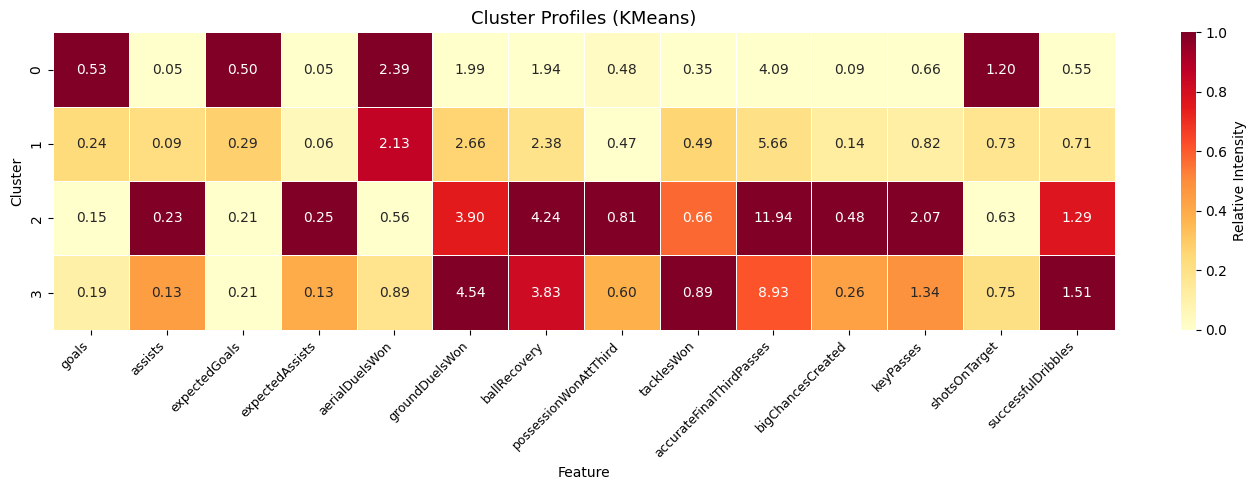

In [32]:
# Heatmap of cluster profiles with normalized colors but real values as annotations
profile_normalized = (cluster_profile_kmeans_4 - cluster_profile_kmeans_4.min()) / \
                     (cluster_profile_kmeans_4.max() - cluster_profile_kmeans_4.min())

plt.figure(figsize=(14, 5))
sns.heatmap(
    profile_normalized,
    annot=cluster_profile_kmeans_4.values,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relative Intensity"}
)
plt.title("Cluster Profiles (KMeans)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
# Players by cluster
print("=== Players by Cluster (KMeans) ===\n")
for c in sorted(dataset_forwards["cluster_kmeans_4"].unique()):
    players = dataset_forwards[dataset_forwards["cluster_kmeans_4"] == c]["player"].tolist()
    print(f"Cluster {c} ({len(players)} players): {', '.join(players)}\n")

=== Players by Cluster (KMeans) ===

Cluster 0 (19 players): Erling Haaland, Igor Thiago, Ollie Watkins, Zian Flemming, Eli Junior Kroupi, William Osula, Benjamin Šeško, Jean Philippe Mateta, Valentín Castellanos, Lukas Nmecha, Dominic Calvert-Lewin, Danny Welbeck, Callum Wilson, Donyell Malen, Wilson Isidor, Beto, Viktor Gyökeres, Chris Wood, Thierno Barry

Cluster 1 (27 players): João Pedro, Hugo Ekitiké, Richarlison, Bryan Mbeumo, Ismaïla Sarr, Dominic Solanke, Harvey Barnes, Raúl Jiménez, Nick Woltemade, Brian Brobbey, Brennan Johnson, Evanilson, Adam Armstrong, Anthony Elanga, Igor Jesus, Hwang Hee-chan, Alexander Isak, Tolu Arokodare, Loum Tchaouna, Rodrigo Muniz, Jacob Bruun Larsen, Eliezer Mayenda, Joshua Zirkzee, Lyle Foster, Liam Delap, Armando Broja, Jørgen Strand Larsen

Cluster 2 (5 players): Bukayo Saka, Samuel Chukwueze, Yéremy Pino, Alejandro Garnacho, Marcus Edwards

Cluster 3 (17 players): Matheus Cunha, Anthony Gordon, Leandro Trossard, Noah Okafor, Amad Diallo, Mate